# Minnie Cell Types from Schema (ClusterMembership → leaf nodes)

Load Minnie65 cell type assignments from the combined delta lake `clustermembership` table,
filter to the leafmost (deepest) cluster node per cell, and produce a DataFrame matching
the `id` + `predicted_label` format used in `yy09_01_label_transfer_into_schema.ipynb`.

In [36]:
import os
import polars as pl
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import json

%load_ext autoreload
%autoreload 2

# Path detection: use combined delta lake if available, else fall back to native microns data
COMBINED_ROOT = "/scratch/combined_datasets"
MICRONS_ROOT = "/data/microns1412"

if os.path.exists(COMBINED_ROOT):
    DATA_ROOT = COMBINED_ROOT
    print(f"Using combined delta lake: {DATA_ROOT}")
else:
    DATA_ROOT = MICRONS_ROOT
    print(f"Using native microns data: {DATA_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using combined delta lake: /scratch/combined_datasets


## 1. Load ClusterMembership for Minnie65

In [3]:
df_cm = (
    pl.read_delta(os.path.join(DATA_ROOT, 'clustermembership'))
    .filter(pl.col('project_id') == 'minnie65')
)
print(f"ClusterMembership rows for minnie65: {len(df_cm)}")
print(f"Unique cells: {df_cm['item'].n_unique()}")
df_cm.head(5)

ClusterMembership rows for minnie65: 107340
Unique cells: 35780


item,cluster,membership_score,probability,distance,project_id
str,str,f64,f64,f64,str
"""204945""","""neuron""",null,1.0,null,"""minnie65"""
"""204945""","""glutamatergic""",null,null,null,"""minnie65"""
"""204945""","""L6CT""",null,null,null,"""minnie65"""
"""524777""","""neuron""",null,1.0,null,"""minnie65"""
"""524777""","""glutamatergic""",null,null,null,"""minnie65"""


## 2. Load Cluster hierarchy for Minnie65

In [4]:
df_clusters = (
    pl.read_delta(os.path.join(DATA_ROOT, 'cluster'))
    .filter(pl.col('project_id') == 'minnie65')
)
print(f"Cluster rows for minnie65: {len(df_clusters)}")
df_clusters

Cluster rows for minnie65: 16


id,parent,children,level,score,hex_color,heirachy_category,distance_to_parent,project_id
str,str,list[str],i64,f64,str,str,f64,str
"""neuron""",null,"[""glutamatergic"", ""gabaergic""]",0,null,"""#000000""","""major_class""",null,"""minnie65"""
"""gabaergic""","""neuron""","[""PTC"", ""DTC"", … ""STC""]",1,null,"""#0000FF""","""class""",null,"""minnie65"""
"""glutamatergic""","""neuron""","[""L4IT"", ""L6CT"", … ""L6SP""]",1,null,"""#FF0000""","""class""",null,"""minnie65"""
"""PTC""","""gabaergic""",null,2,null,"""#364a7a""","""subtype""",null,"""minnie65"""
"""DTC""","""gabaergic""",null,2,null,"""#80c5c0""","""subtype""",null,"""minnie65"""
…,…,…,…,…,…,…,…,…
"""L5IT""","""glutamatergic""",null,2,null,"""#b76969""","""subtype""",null,"""minnie65"""
"""L6IT""","""glutamatergic""",null,2,null,"""#7d354c""","""subtype""",null,"""minnie65"""
"""L5ET""","""glutamatergic""",null,2,null,"""#c68076""","""subtype""",null,"""minnie65"""


In [5]:
# Inspect cluster levels
df_clusters.group_by(['level', 'heirachy_category']).agg(pl.len().alias('count')).sort('level')

level,heirachy_category,count
i64,str,u32
0,"""major_class""",1
1,"""class""",2
2,"""subtype""",13


## 3. Get leafmost (deepest) cluster per cell

Join ClusterMembership with the cluster hierarchy to get `level` per row,
then keep only the row with the highest level (deepest node) per cell.
This is the same strategy used in `yy07_01_EM_to_patchseq_types-EXC.ipynb`.

In [6]:
df_minnie_types = (
    df_cm
    .select(['item', 'cluster'])
    .join(
        df_clusters.select(['id', 'level', 'heirachy_category']),
        left_on='cluster', right_on='id',
        how='left'
    )
    # Sort by level descending so the deepest (leafmost) node comes first
    .sort('level', descending=True, nulls_last=True)
    # Keep only the deepest node per cell
    .group_by('item')
    .first()
    .select(['item', 'cluster', 'level', 'heirachy_category'])
)
print('Label distribution by hierarchy category:')
print(df_minnie_types.group_by('heirachy_category').agg(pl.len().alias('count')).sort('count', descending=True))
df_minnie_types.head(5)

Label distribution by hierarchy category:
shape: (1, 2)
┌───────────────────┬───────┐
│ heirachy_category ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ subtype           ┆ 35780 │
└───────────────────┴───────┘


item,cluster,level,heirachy_category
str,str,i64,str
"""309579""","""L6CT""",2,"""subtype"""
"""524573""","""STC""",2,"""subtype"""
"""273338""","""L6CT""",2,"""subtype"""
"""453726""","""L2IT""",2,"""subtype"""
"""269326""","""L5ET""",2,"""subtype"""


In [7]:
# Distribution of leaf-level cell types
df_minnie_types.group_by('cluster').agg(pl.len().alias('count')).sort('count', descending=True)

cluster,count
str,u32
"""L4IT""",7348
"""L6CT""",7245
"""L2IT""",5038
"""L3IT""",4444
"""L5IT""",3327
…,…
"""L5ET""",865
"""ITC""",662
"""STC""",460


## 4. Format to match yy09_01 DataFrame format

Target format: `id` (int, cell ID) + `predicted_label` (str, cell type),
matching `mmc_df` in `yy09_01_label_transfer_into_schema.ipynb`.

In [8]:
minnie_labels_df = (
    df_minnie_types
    .select([
        pl.col('item').cast(pl.Int64).alias('id'),
        pl.col('cluster').alias('predicted_label')
    ])
    .to_pandas()
)
print(f"Total minnie cells with leaf-level type: {len(minnie_labels_df)}")
minnie_labels_df

Total minnie cells with leaf-level type: 35780


,id,predicted_label
0,309579,L6CT
1,524573,STC
2,273338,L6CT
3,453726,L2IT
4,269326,L5ET
...,...,...
35775,520285,L3IT
35776,240184,L6CT
35777,333498,PTC
35778,359336,L3IT


## 5. (Optional) Split into EXC and INH subsets

Matching `yy09_01`'s focus on excitatory cells (`exc_minnie_met_umapknn.h5ad`).

In [ ]:
exc_subtypes = ['L2IT', 'L3IT', 'L4IT', 'L5ET', 'L5IT', 'L5NP', 'L6CT', 'L6IT', 'L6SP']
inh_subtypes = ['DTC', 'ITC', 'PTC', 'STC']

minnie_exc_df = minnie_labels_df[minnie_labels_df['predicted_label'].isin(exc_subtypes)].copy()
minnie_inh_df = minnie_labels_df[minnie_labels_df['predicted_label'].isin(inh_subtypes)].copy()

print(f"EXC cells: {len(minnie_exc_df)}")
print(f"INH cells: {len(minnie_inh_df)}")
print(f"Unlabeled (not subtype-level): {len(minnie_labels_df) - len(minnie_exc_df) - len(minnie_inh_df)}")

minnie_exc_df.head()

In [ ]:
minnie_inh_df.head()

## 6. read umapknn predictions EXc

In [63]:
adata = ad.read_h5ad('/scratch/h5ad_outputs/exc_minnie_met_umapknn_wScores.h5ad')
umapknndf = adata.obs
umapknndf

,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,23141,L6b,1.0,1.137475,NaN,NaN,NaN,NaN,NaN,NaN
1,23332,L6 IT-1,0.8,0.831320,L6b,0.2,0.690846,NaN,NaN,NaN
2,23373,L5 IT-2,1.0,1.560962,NaN,NaN,NaN,NaN,NaN,NaN
3,23382,L6 IT-1,0.8,0.753741,L6b,0.2,0.817720,NaN,NaN,NaN
4,23385,L5 IT-2,1.0,1.461509,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
49709,764787,L5/L6 IT Car3,0.8,0.295505,L5 ET-1 Chrna6,0.2,0.233661,NaN,NaN,NaN
49710,766128,L5/L6 IT Car3,0.8,0.357998,L5 ET-1 Chrna6,0.2,0.253444,NaN,NaN,NaN
49711,766409,L5/L6 IT Car3,0.8,0.609389,L5 ET-1 Chrna6,0.2,0.468461,NaN,NaN,NaN
49712,766554,L5/L6 IT Car3,0.8,0.335062,L5 ET-1 Chrna6,0.2,0.273921,NaN,NaN,NaN


In [64]:
# Normalize IDs to int64 so joins between umapknndf and minnie_labels_df work correctly.
# AnnData .obs stores IDs as strings by default; minnie_labels_df was cast to Int64 in cell above.
umapknndf = umapknndf.copy()
umapknndf["id"] = umapknndf["id"].astype("int64")
minnie_labels_df["id"] = minnie_labels_df["id"].astype("int64")

print(f"umapknndf id dtype      : {umapknndf['id'].dtype}")
print(f"minnie_labels_df id dtype: {minnie_labels_df['id'].dtype}")
print(f"Overlap count: {minnie_labels_df['id'].isin(umapknndf['id']).sum()}")

umapknndf id dtype      : int64
minnie_labels_df id dtype: int64
Overlap count: 29321


## 7. read MMC predictions EXC

In [37]:
## MMC results
with open('/data/MMC-minnie-from-patchseq-v2/exc_mapping.json', 'rb') as src:
    mapping = json.load(src)

In [38]:
mapping.keys()

dict_keys(['marker_genes', 'taxonomy_tree', 'n_unmapped_genes', 'gene_identifier_mapping', 'config', 'log', 'metadata', 'results'])

In [39]:
mapping['results'][0]

{'cluster': {'assignment': 'L6 IT-3',
  'bootstrapping_probability': 0.5,
  'aggregate_probability': 0.5,
  'avg_correlation': 0.8007693105307575,
  'runner_up_assignment': ['L6b', 'L5/L6 IT Car3'],
  'runner_up_correlation': [0.7117746375196076, 0.909296897228225],
  'runner_up_probability': [0.25, 0.25],
  'directly_assigned': True},
 'cell_id': '23141'}

### put mmc mapping results into id label table like the umap+knn results

In [44]:
mmc_df = pd.DataFrame([
    {"id": int(r["cell_id"]), "predicted_label": r["cluster"]["assignment"], "prob":r['cluster']['aggregate_probability'], "corr":r['cluster']['avg_correlation']}
    for r in mapping["results"]
])
mmc_df

,id,predicted_label,prob,corr
0,23141,L6 IT-3,0.500000,0.800769
1,23332,L6 IT-3,0.607143,0.652760
2,23373,L6 IT-3,0.678571,0.769960
3,23382,L6 IT-3,0.607143,0.540798
4,23385,L6 IT-3,0.500000,0.791378
...,...,...,...,...
49709,764787,L6 IT-3,0.571429,0.616343
49710,766128,L6 IT-3,0.571429,0.667053
49711,766409,L6 IT-3,0.714286,0.531405
49712,766554,L6 IT-3,0.571429,0.741294


## 8. read umapknn predictions INH

In [65]:
adata_inh = ad.read_h5ad('/scratch/h5ad_outputs/inh_minnie_met_umapknn_wScores.h5ad')
umapknn_inh_df = adata_inh.obs.copy()
umapknn_inh_df["id"] = umapknn_inh_df["id"].astype("int64")

print(f"umapknn_inh_df id dtype: {umapknn_inh_df['id'].dtype}")
print(f"Overlap count: {minnie_labels_df['id'].isin(umapknn_inh_df['id']).sum()}")
umapknn_inh_df

umapknn_inh_df id dtype: int64
Overlap count: 161


,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,252232,Sst-MET-9,1.0,0.145963,NaN,NaN,NaN,NaN,NaN,NaN
1,255120,Vip-MET-5,0.8,0.556023,Sst-MET-2,0.2,0.640061,NaN,NaN,NaN
2,255129,Sst-MET-11,0.4,0.571345,Sst-MET-7,0.4,1.121178,Sst-MET-6,0.2,1.138083
3,255137,Vip-MET-5,1.0,0.875754,NaN,NaN,NaN,NaN,NaN,NaN
4,255208,Vip-MET-5,1.0,0.670438,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
158,309481,Sncg-MET-1,1.0,0.703897,NaN,NaN,NaN,NaN,NaN,NaN
159,309508,Vip-MET-1,0.6,0.154413,Pvalb-MET-5,0.2,0.154606,Vip-MET-3,0.2,0.200278
160,309578,Vip-MET-1,0.6,0.138265,Pvalb-MET-5,0.2,0.061309,Vip-MET-3,0.2,0.117908
161,342232,Pvalb-MET-3,1.0,0.761696,NaN,NaN,NaN,NaN,NaN,NaN


## 9. read MMC predictions INH

In [50]:
## MMC INH results
with open('/data/MMC-minnie-from-patchseq-v2/inh_mapping_wclusterHierachy.json', 'rb') as src:
    mapping_inh = json.load(src)

In [51]:
mmc_inh_df = pd.DataFrame([
    {"id": int(r["cell_id"]), "predicted_label": r["cluster"]["assignment"],
     "prob": r["cluster"]["aggregate_probability"], "corr": r["cluster"]["avg_correlation"]}
    for r in mapping_inh["results"]
])
mmc_inh_df

,id,predicted_label,prob,corr
0,252232,Vip-MET-2,0.642857,0.728378
1,255120,Sncg-MET-2,0.357143,0.531037
2,255129,Vip-MET-5,0.464286,0.615556
3,255137,Lamp5-MET-1,0.285714,0.593101
4,255208,Sncg-MET-2,0.321429,0.619237
...,...,...,...,...
158,309481,Sst-MET-13,0.464286,0.641485
159,309508,Vip-MET-3,0.607143,0.565286
160,309578,Pvalb-MET-2,0.857143,0.843957
161,342232,Sst-MET-6,0.500000,0.668974


# Compare the labels

/tmp/ipykernel_633/600382048.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  sortedlist = sorted(umapknndf.predicted_label.unique().to_list())
/tmp/ipykernel_633/600382048.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha="right")
/tmp/ipykernel_633/600382048.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha="right")
/tmp/ipykernel_633/600382048.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha="right")
/tmp/ipykernel_633/600382048.py:11: UserWarning: set_ticklabels() should only be used 

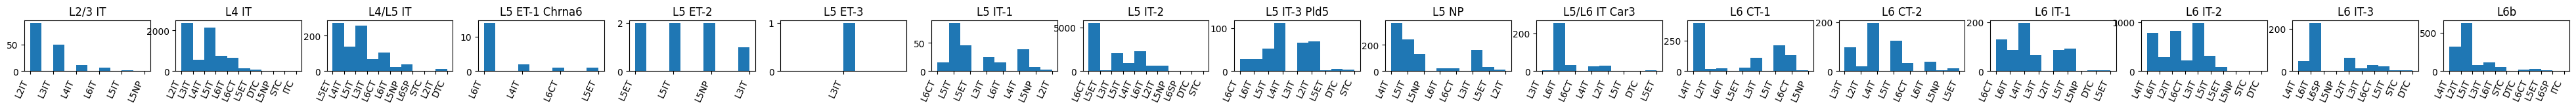

In [30]:
sortedlist = sorted(umapknndf.predicted_label.unique().to_list())
fig, axes = plt.subplots(nrows=1, ncols=len(sortedlist), figsize=[50,1])

for l, ll in enumerate(sortedlist):
    ax = axes[l]
    # Get cell IDs (from the "id" column, not the sequential index) for this umapknn label
    ids_for_label = umapknndf[umapknndf["predicted_label"] == ll]["id"]
    # Filter minnie_labels_df by those IDs to get the corresponding minnie predicted labels
    minnie_preds = minnie_labels_df[minnie_labels_df["id"].isin(ids_for_label)]["predicted_label"]
    ax.hist(minnie_preds)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha="right")
    ax.set_title(ll)
plt.show()


# confusion matrix of labels

In [ ]:
import colorcet as cc
import seaborn as sns

## Minnie vs umap

Matched cells: 29321


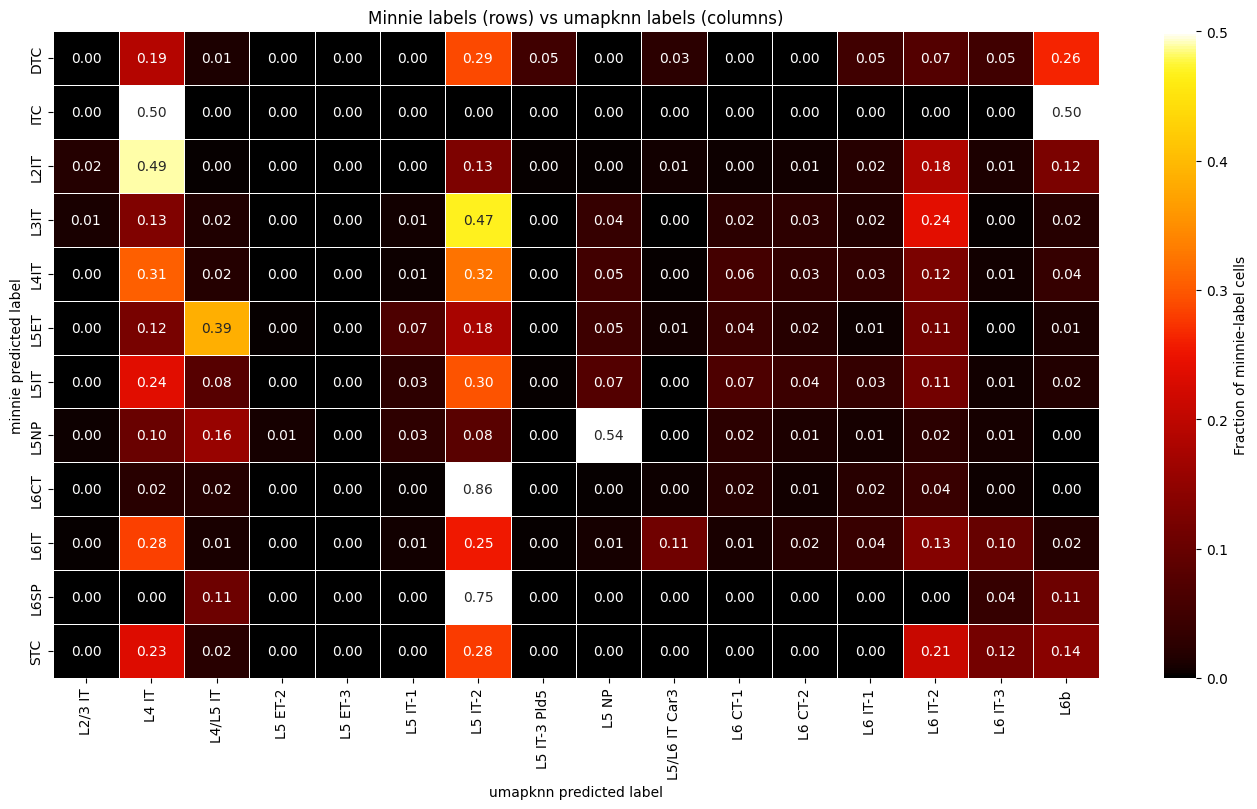

In [66]:
# Join on id to align labels from both sources
merged = (
    umapknndf[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

# Build count crosstab: rows = minnie labels, cols = umapknn labels
ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])

# Row-normalize so each minnie label row sums to 1 (fraction going to each umapknn label)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("umapknn predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("Minnie labels (rows) vs umapknn labels (columns)")
plt.tight_layout()
plt.show()

## Minnie vs filtered umap

<Axes: >

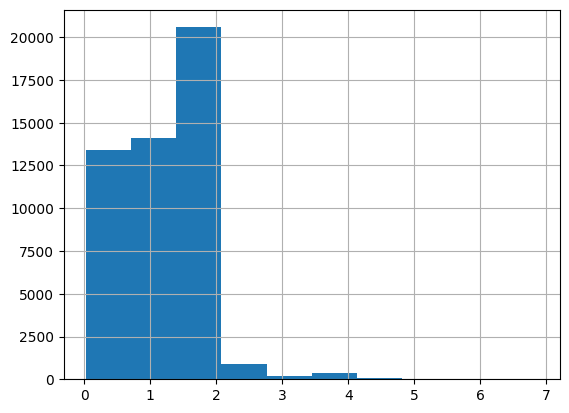

In [71]:
umapknndf.predicted_avg_distance.hist()

In [68]:
umapknndf.head()

,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,23141,L6b,1.0,1.137475,NaN,NaN,NaN,NaN,NaN,NaN
1,23332,L6 IT-1,0.8,0.831320,L6b,0.2,0.690846,NaN,NaN,NaN
2,23373,L5 IT-2,1.0,1.560962,NaN,NaN,NaN,NaN,NaN,NaN
3,23382,L6 IT-1,0.8,0.753741,L6b,0.2,0.817720,NaN,NaN,NaN
4,23385,L5 IT-2,1.0,1.461509,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
umapknndf_filtered = umapknndf[(umapknndf["predicted_probability"] > 0.7) & (umapknndf["predicted_avg_distance"] < 1.5)]

Matched cells: 15656


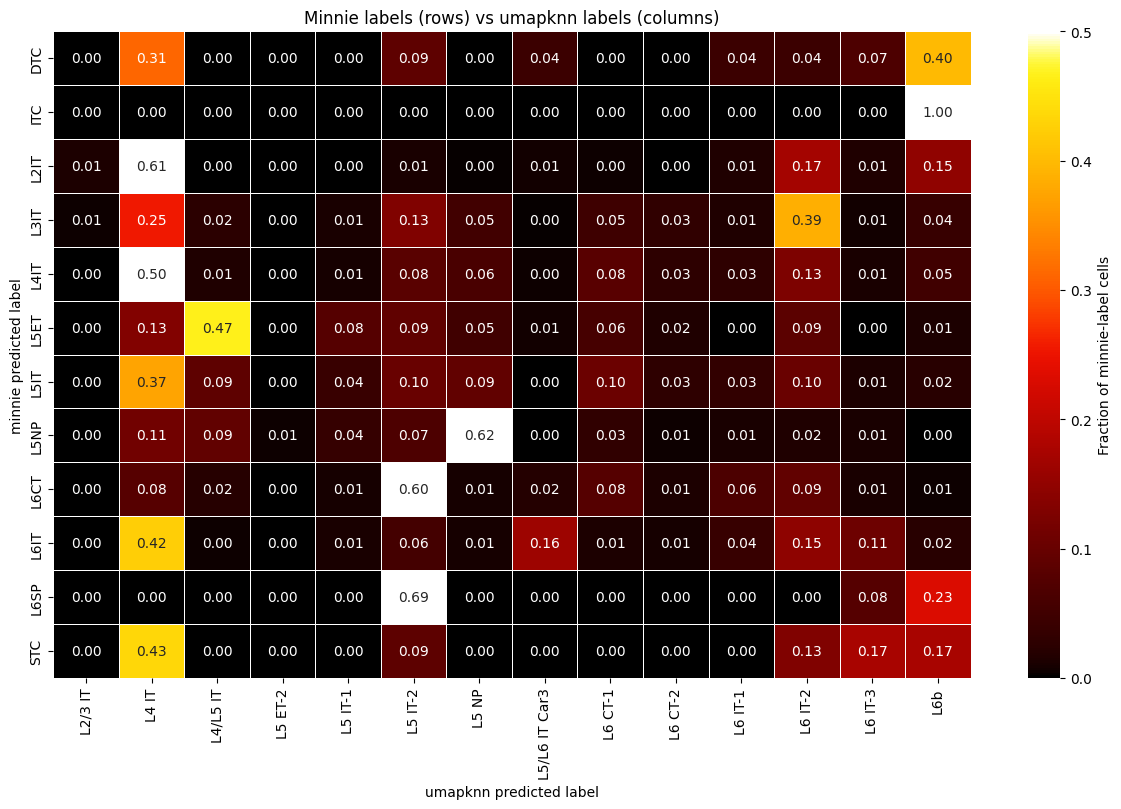

In [83]:
# Join on id to align labels from both sources
merged = (
    umapknndf_filtered[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

# Build count crosstab: rows = minnie labels, cols = umapknn labels
ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])

# Row-normalize so each minnie label row sums to 1 (fraction going to each umapknn label)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("umapknn predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("Minnie labels (rows) vs umapknn labels (columns)")
plt.tight_layout()
plt.show()

## Minnie vs MMC

Matched cells: 29321


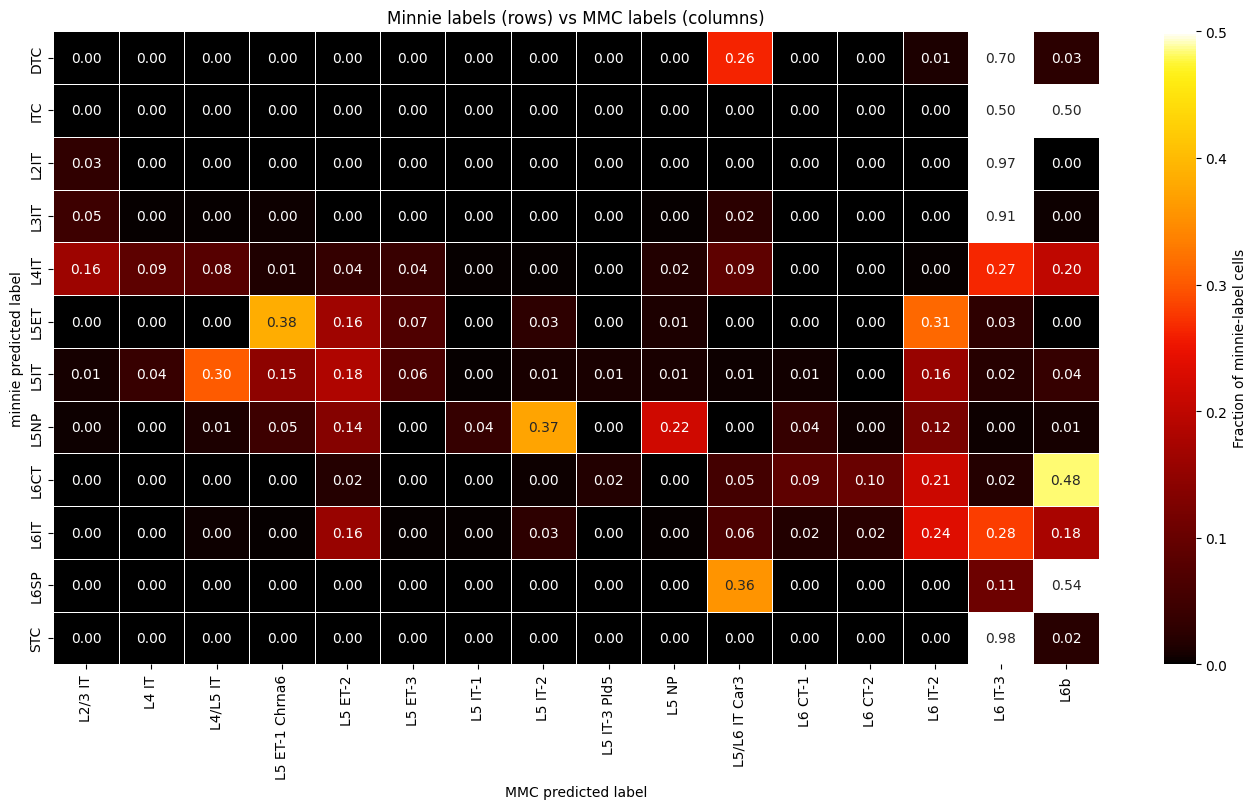

In [42]:
# Join on id to align labels from both sources
merged = (
    mmc_df[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

# Build count crosstab: rows = minnie labels, cols = umapknn labels
ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])

# Row-normalize so each minnie label row sums to 1 (fraction going to each umapknn label)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("MMC predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("Minnie labels (rows) vs MMC labels (columns)")
plt.tight_layout()
plt.show()

## Minnie vs Filtered MMC

In [45]:
mmc_df.head()

,id,predicted_label,prob,corr
0,23141,L6 IT-3,0.500000,0.800769
1,23332,L6 IT-3,0.607143,0.652760
2,23373,L6 IT-3,0.678571,0.769960
3,23382,L6 IT-3,0.607143,0.540798
4,23385,L6 IT-3,0.500000,0.791378


In [48]:
mmc_filtered = mmc_df[(mmc_df["prob"] > 0.8) & (mmc_df["corr"] > 0.7)]

Matched cells: 1445


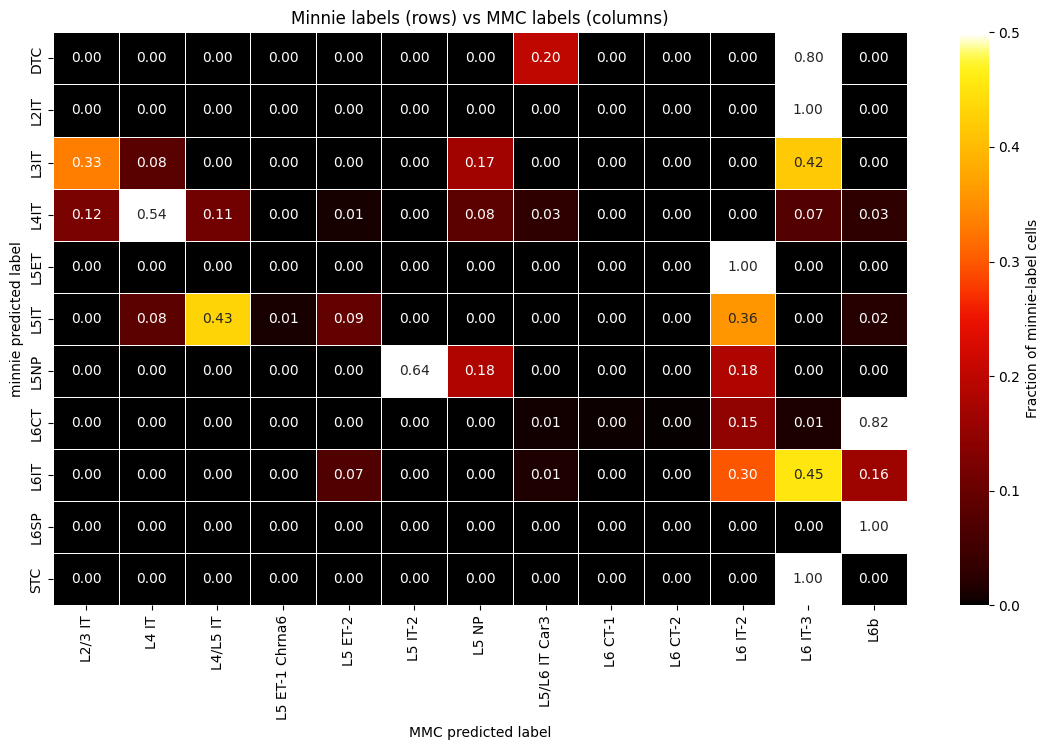

In [49]:
# Join on id to align labels from both sources
merged = (
    mmc_filtered[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

# Build count crosstab: rows = minnie labels, cols = umapknn labels
ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])

# Row-normalize so each minnie label row sums to 1 (fraction going to each umapknn label)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("MMC predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("Minnie labels (rows) vs MMC labels (columns)")
plt.tight_layout()
plt.show()

# Confusion matrices — INH cells

## INH: Minnie vs umapknn

Matched cells: 161


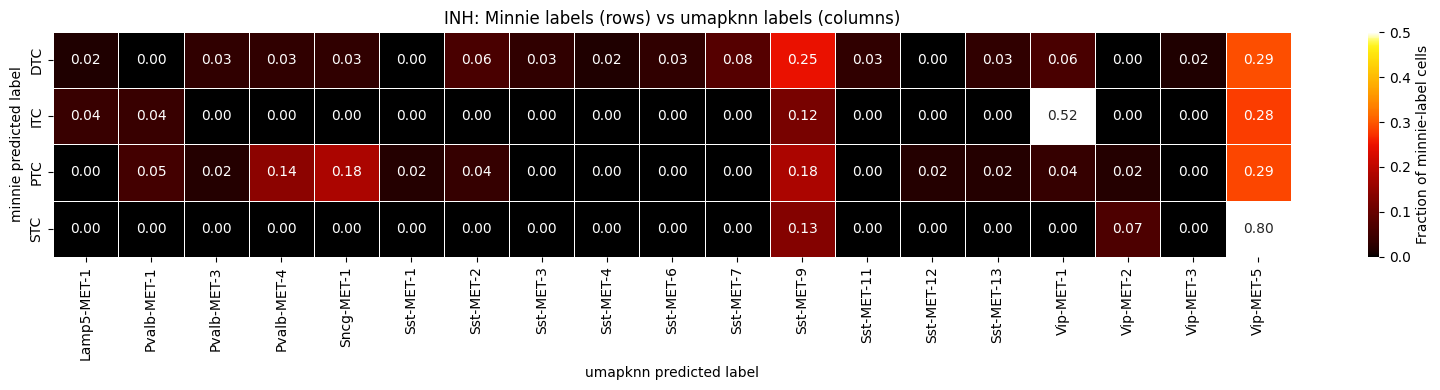

In [67]:
# Join on id to align labels from both sources
merged = (
    umapknn_inh_df[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("umapknn predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("INH: Minnie labels (rows) vs umapknn labels (columns)")
plt.tight_layout()
plt.show()

## INH: Minnie vs MMC

Matched cells: 161


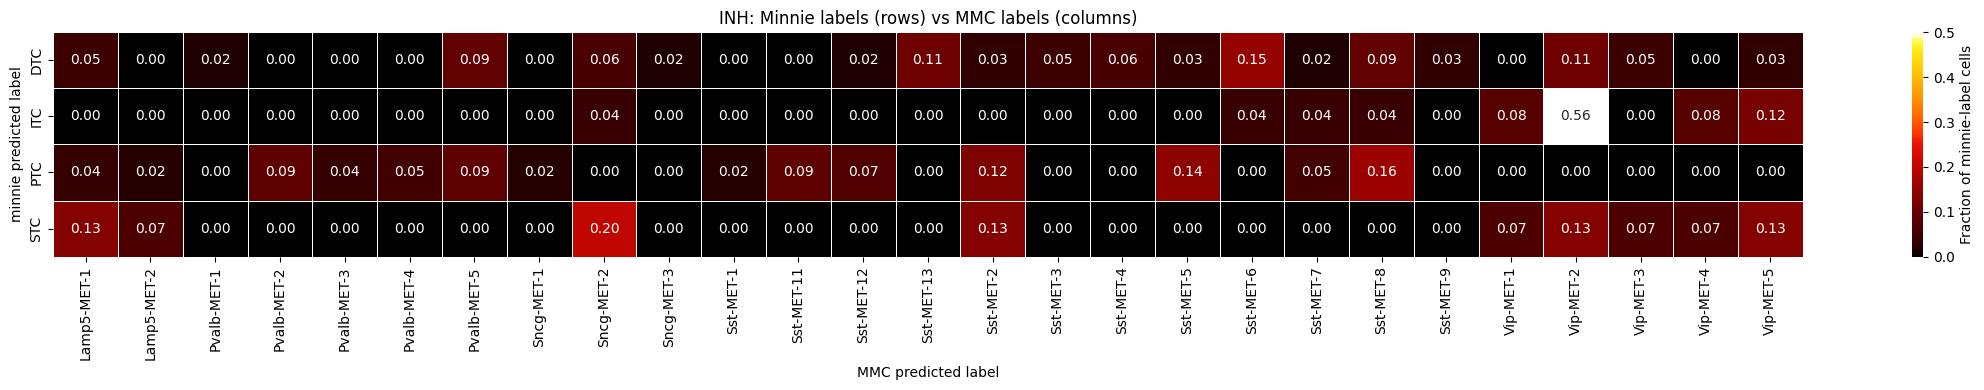

In [54]:
# Join on id to align labels from both sources
merged = (
    mmc_inh_df[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("MMC predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("INH: Minnie labels (rows) vs MMC labels (columns)")
plt.tight_layout()
plt.show()

## INH: Minnie vs Filtered MMC

In [55]:
mmc_inh_filtered = mmc_inh_df[(mmc_inh_df["prob"] > 0.8) & (mmc_inh_df["corr"] > 0.7)]

Matched cells: 22


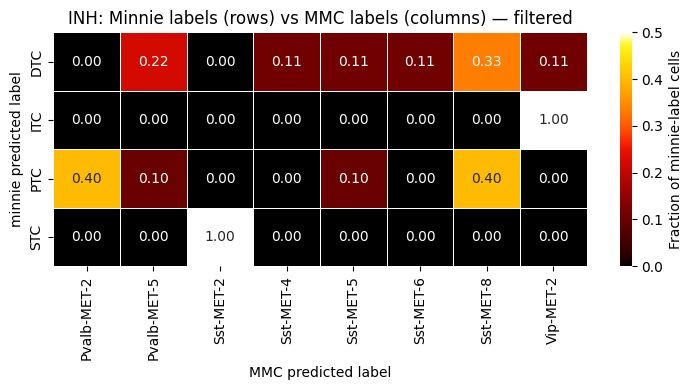

In [56]:
# Join on id to align labels from both sources
merged = (
    mmc_inh_filtered[["id", "predicted_label"]].rename(columns={"predicted_label": "umapknn_label"})
    .merge(minnie_labels_df[["id", "predicted_label"]].rename(columns={"predicted_label": "minnie_label"}),
           on="id", how="inner")
)
print(f"Matched cells: {len(merged)}")

ct = pd.crosstab(merged["minnie_label"], merged["umapknn_label"])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(ct.columns) * 0.8 + 1),
                                max(4, len(ct.index) * 0.6 + 1)))
sns.heatmap(
    ct_norm,
    ax=ax,
    cmap=cc.fire,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=0.5,
    cbar_kws={"label": "Fraction of minnie-label cells"},
)
ax.set_xlabel("MMC predicted label")
ax.set_ylabel("minnie predicted label")
ax.set_title("INH: Minnie labels (rows) vs MMC labels (columns) — filtered")
plt.tight_layout()
plt.show()